In [3]:
import pandas as pd
df = pd.read_csv("/Users/tanmayjagtap/Desktop/retail-customer-insights-ai-testing/data/processed/retail_transactions_clean.csv")
df.head()

,transaction_id,customer_id,transaction_date,store_id,region,product_id,product_category,product_name,quantity,unit_price,total_amount,payment_method,loyalty_member,basket_size
0,T000001,C0655,2025-04-25,S101,Midwest,P012,Dairy,Yogurt,2,1.49,2.98,Debit Card,No,3
1,T000002,C0755,2025-01-16,S101,Midwest,P010,Household,Detergent,5,8.99,44.95,Credit Card,No,2
2,T000003,C0224,2025-04-23,S102,Midwest,P009,Frozen,Ice Cream,3,5.49,16.47,Mobile Pay,Yes,8
3,T000004,C0604,2025-06-24,S103,Midwest,P013,Snacks,Cookies,2,3.99,7.98,Mobile Pay,Yes,5
4,T000005,C0160,2025-02-19,S102,West,P002,Bakery,Bread,1,2.49,2.49,Mobile Pay,Yes,6


In [ ]:
# RFM Customer Segmentation
# Recency: how recently they purchased
# Frequency: how often they purchased
# Monetary: how much they spent

In [4]:
import pandas as pd
import numpy as np

# Make transaction_date is in datetime format
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Reference date as one day after the latest transaction
reference_date = df["transaction_date"].max() + pd.Timedelta(days=1)

# Group by customer and calculate:
# Recency - days since last purchase
# Frequency - number of unique transactions
# Monetary - total amount spent
rfm = df.groupby("customer_id").agg({
    "transaction_date": lambda x: (reference_date - x.max()).days,
    "transaction_id": "nunique",
    "total_amount": "sum"
}).reset_index()

rfm.columns = ["customer_id", "recency", "frequency", "monetary"]
rfm.head()

,customer_id,recency,frequency,monetary
0,C0001,42,6,84.38
1,C0002,34,11,120.12
2,C0003,29,5,56.15
3,C0004,57,12,71.56
4,C0005,41,11,78.56


In [5]:
# RFM scores using quartiles
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4])

# Convert scores to integers
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

# Total RFM score
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,C0001,42,6,84.38,2,1,2,5
1,C0002,34,11,120.12,2,3,4,9
2,C0003,29,5,56.15,2,1,1,4
3,C0004,57,12,71.56,1,3,2,6
4,C0005,41,11,78.56,2,3,2,7


In [6]:
# Assigned customer segment based on RFM score
def segment_customer(score):
    if score >= 10:
        return "High Value"
    elif score >= 8:
        return "Loyal"
    elif score >= 6:
        return "At Risk"
    else:
        return "Low Engagement"

rfm["segment"] = rfm["RFM_score"].apply(segment_customer)
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,C0001,42,6,84.38,2,1,2,5,Low Engagement
1,C0002,34,11,120.12,2,3,4,9,Loyal
2,C0003,29,5,56.15,2,1,1,4,Low Engagement
3,C0004,57,12,71.56,1,3,2,6,At Risk
4,C0005,41,11,78.56,2,3,2,7,At Risk


In [7]:
# Count customers in each segment
segment_summary = rfm["segment"].value_counts().reset_index()
segment_summary.columns = ["segment", "customer_count"]

segment_summary

,segment,customer_count
0,High Value,269
1,Low Engagement,248
2,At Risk,248
3,Loyal,235


In [8]:
# Merge segment into transaction data
df_segmented = df.merge(rfm[["customer_id", "segment"]], on="customer_id", how="left")

# Calculate revenue by segment
revenue_by_segment = df_segmented.groupby("segment")["total_amount"].sum().reset_index()
revenue_by_segment = revenue_by_segment.sort_values(by="total_amount", ascending=False)

revenue_by_segment

,segment,total_amount
1,High Value,35189.15
3,Loyal,23131.89
0,At Risk,18617.29
2,Low Engagement,13181.58


Matplotlib is building the font cache; this may take a moment.


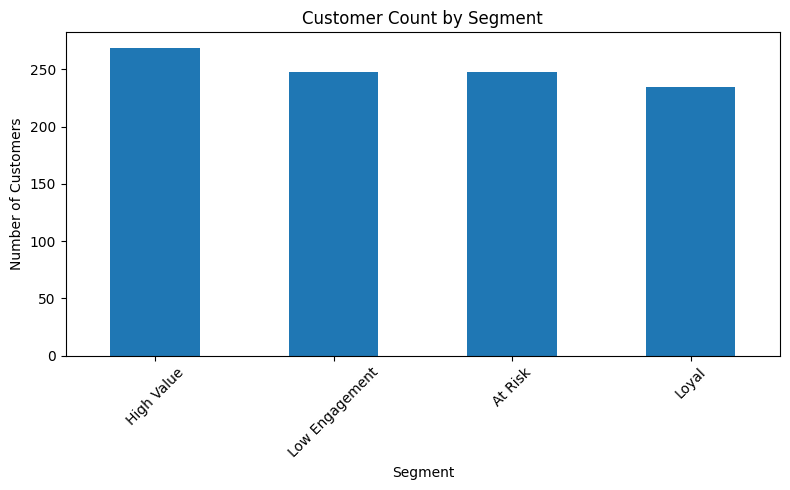

In [9]:
import matplotlib.pyplot as plt

# Plot customer count by segment
segment_counts = rfm["segment"].value_counts()
plt.figure(figsize=(8, 5))
segment_counts.plot(kind="bar")
plt.title("Customer Count by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

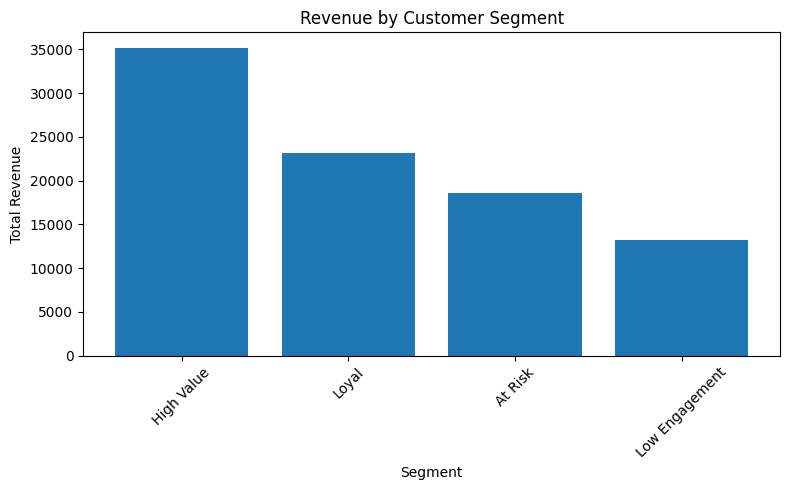

In [10]:
# Plot revenue by segment
plt.figure(figsize=(8, 5))
plt.bar(revenue_by_segment["segment"], revenue_by_segment["total_amount"])
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
## Loyalty vs Non-Loyalty Customer Analysis
# Revenue by loyalty status

loyalty_revenue = df.groupby("loyalty_member")["total_amount"].sum().reset_index()
loyalty_revenue

,loyalty_member,total_amount
0,No,45691.53
1,Yes,44428.38


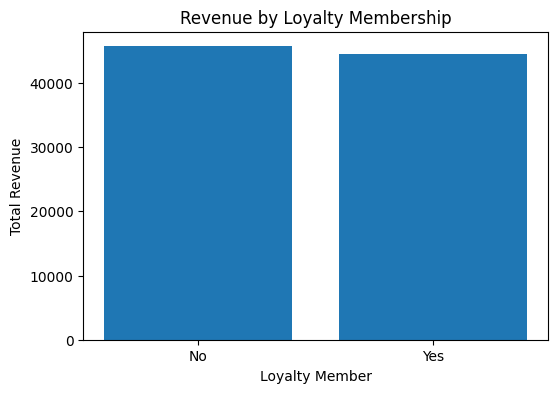

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(loyalty_revenue["loyalty_member"], loyalty_revenue["total_amount"])
plt.title("Revenue by Loyalty Membership")
plt.xlabel("Loyalty Member")
plt.ylabel("Total Revenue")
plt.show()

In [13]:
## Product Category Performance
category_revenue = df.groupby("product_category")["total_amount"].sum().reset_index()
category_revenue = category_revenue.sort_values(by="total_amount", ascending=False)
category_revenue

,product_category,total_amount
4,Household,23906.39
3,Frozen,17680.71
2,Dairy,14849.32
7,Snacks,10986.69
1,Beverages,8384.32
6,Produce,6265.23
5,Personal Care,4568.72
0,Bakery,3478.53


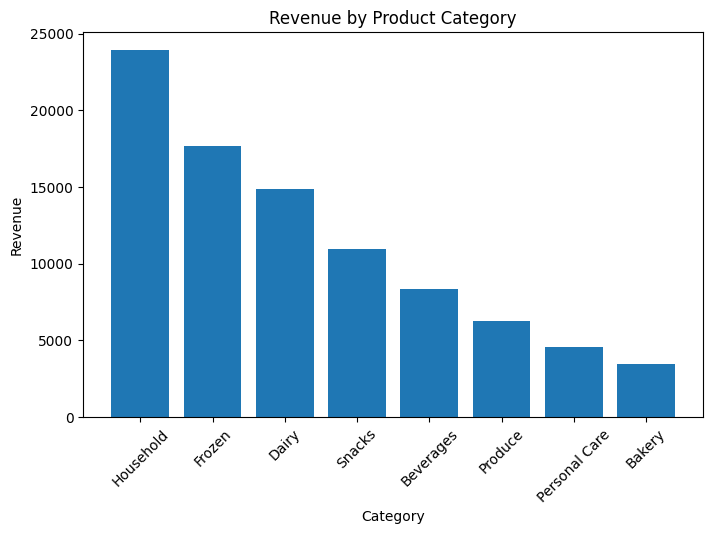

In [14]:
plt.figure(figsize=(8,5))
plt.bar(category_revenue["product_category"], category_revenue["total_amount"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Region Analysis
region_revenue = df.groupby("region")["total_amount"].sum().reset_index()
region_revenue = region_revenue.sort_values(by="total_amount", ascending=False)
region_revenue

,region,total_amount
1,Northeast,23118.20
0,Midwest,22668.07
3,West,22447.37
2,South,21886.27


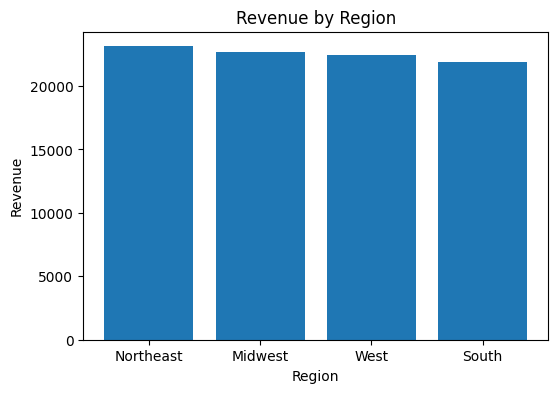

In [16]:
plt.figure(figsize=(6,4))
plt.bar(region_revenue["region"], region_revenue["total_amount"])
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

In [17]:
## AI Insight Generator
def generate_insights(df, rfm):

    insights = []

    # 1. Top revenue segment
    revenue_by_segment = df.groupby("segment")["total_amount"].sum().reset_index()
    top_segment = revenue_by_segment.sort_values(by="total_amount", ascending=False).iloc[0]

    insights.append(f"Top revenue is generated by '{top_segment['segment']}' customers.")

    # 2. Loyalty insight
    loyalty_revenue = df.groupby("loyalty_member")["total_amount"].sum().reset_index()
    top_loyalty = loyalty_revenue.sort_values(by="total_amount", ascending=False).iloc[0]

    insights.append(f"Customers with '{top_loyalty['loyalty_member']}' loyalty status contribute more revenue.")

    # 3. Category insight
    category_revenue = df.groupby("product_category")["total_amount"].sum().reset_index()
    top_category = category_revenue.sort_values(by="total_amount", ascending=False).iloc[0]

    insights.append(f"'{top_category['product_category']}' category generates the highest revenue.")

    # 4. Region insight
    region_revenue = df.groupby("region")["total_amount"].sum().reset_index()
    top_region = region_revenue.sort_values(by="total_amount", ascending=False).iloc[0]

    insights.append(f"'{top_region['region']}' region contributes the most revenue.")

    return insights

ai_insights = generate_insights(df_segmented, rfm)
for i, insight in enumerate(ai_insights, 1):
    print(f"{i}. {insight}")

1. Top revenue is generated by 'High Value' customers.
2. Customers with 'No' loyalty status contribute more revenue.
3. 'Household' category generates the highest revenue.
4. 'Northeast' region contributes the most revenue.


In [18]:
## AI Stress Testing
def stress_test_ai():

    test_results = []

    # Case 1: Empty DataFrame
    try:
        empty_df = pd.DataFrame()
        generate_insights(empty_df, rfm)
        test_results.append(("Empty Data", "No error (Unexpected)"))
    except Exception as e:
        test_results.append(("Empty Data", str(e)))

    # Case 2: Missing column
    try:
        broken_df = df_segmented.drop(columns=["segment"])
        generate_insights(broken_df, rfm)
        test_results.append(("Missing Column", "No error (Unexpected)"))
    except Exception as e:
        test_results.append(("Missing Column", str(e)))

    # Case 3: Wrong data type
    try:
        wrong_df = df_segmented.copy()
        wrong_df["total_amount"] = "invalid"
        generate_insights(wrong_df, rfm)
        test_results.append(("Wrong Data Type", "No error (Unexpected)"))
    except Exception as e:
        test_results.append(("Wrong Data Type", str(e)))

    return pd.DataFrame(test_results, columns=["Test Case", "Result"])

stress_results = stress_test_ai()
stress_results

,Test Case,Result
0,Empty Data,'segment'
1,Missing Column,'segment'
2,Wrong Data Type,No error (Unexpected)
